In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')
import os

path = r'C:\Users\Anirudh\Desktop\olist_project\\'
os.chdir(path)

master = pd.read_csv('olist_master.csv')
print("Master loaded ✅")

Master loaded ✅


In [2]:
findings = {
    'Metric': [
        'Total Orders Analysed',
        'Delivered Orders',
        'SLA Breach Rate',
        'SLA Compliance Rate',
        'Avg Delay (Late Orders)',
        'Worst State (Breach Rate)',
        'Best State (Breach Rate)',
        'Worst Product Category',
        'Worst Seller Breach Rate',
        'Avg Review — On Time',
        'Avg Review — Late',
        'Review Score Drop',
        'Revenue at Risk (R$)',
        'Revenue at Risk (%)',
        'Revenue Lost to Cancellations',
        'Worst Order Day',
        'Peak Breach Months',
        'YoY Trend'
    ],
    'Value': [
        '99,441',
        '96,455',
        '7.57%',
        '92.43%',
        '~10 days',
        'AM (Amazonas)',
        'SC (Santa Catarina)',
        'Audio',
        '64.29%',
        '4.21 / 5',
        '2.45 / 5',
        '-1.76 points',
        'R$ 1,088,725.53',
        '8.24%',
        'R$ 95,235.27',
        'Monday',
        'April & November',
        'Improving (2017→2018)'
    ],
    'Business Implication': [
        'Large enough for statistically significant conclusions',
        '97% delivery rate — healthy platform overall',
        '1 in 13 orders arrives late — above Amazon benchmark',
        'Below world-class standard of 98%+',
        'When Olist fails, it fails badly — 10 day avg slip',
        'Remote geography + poor infrastructure = last mile failure',
        'Benchmark state — proximity to seller hubs drives compliance',
        'Bulky items with special handling needs drive delays',
        'Seller accountability gap — needs immediate intervention',
        'Satisfied customers correlate with on-time delivery',
        'Late delivery turns happy customers into dissatisfied ones',
        'Massive drop — delivery is the #1 driver of review scores',
        'Revenue exposed to churn risk from poor experience',
        '1 in 12 rupees flows through at-risk orders',
        'Preventable revenue loss from order abandonment',
        'Weekend backlog clears Monday — pushes processing out',
        'Demand surges overwhelm logistics capacity',
        'Operations improving but still far from world class'
    ]
}

findings_df = pd.DataFrame(findings)
findings_df.to_csv('week1_findings_summary.csv', index=False)

print(findings_df.to_string(index=False))
print("\nFindings saved ✅")

                       Metric                 Value                                         Business Implication
        Total Orders Analysed                99,441       Large enough for statistically significant conclusions
             Delivered Orders                96,455                 97% delivery rate — healthy platform overall
              SLA Breach Rate                 7.57%         1 in 13 orders arrives late — above Amazon benchmark
          SLA Compliance Rate                92.43%                           Below world-class standard of 98%+
      Avg Delay (Late Orders)              ~10 days           When Olist fails, it fails badly — 10 day avg slip
    Worst State (Breach Rate)         AM (Amazonas)   Remote geography + poor infrastructure = last mile failure
     Best State (Breach Rate)   SC (Santa Catarina) Benchmark state — proximity to seller hubs drives compliance
       Worst Product Category                 Audio         Bulky items with special handling ne

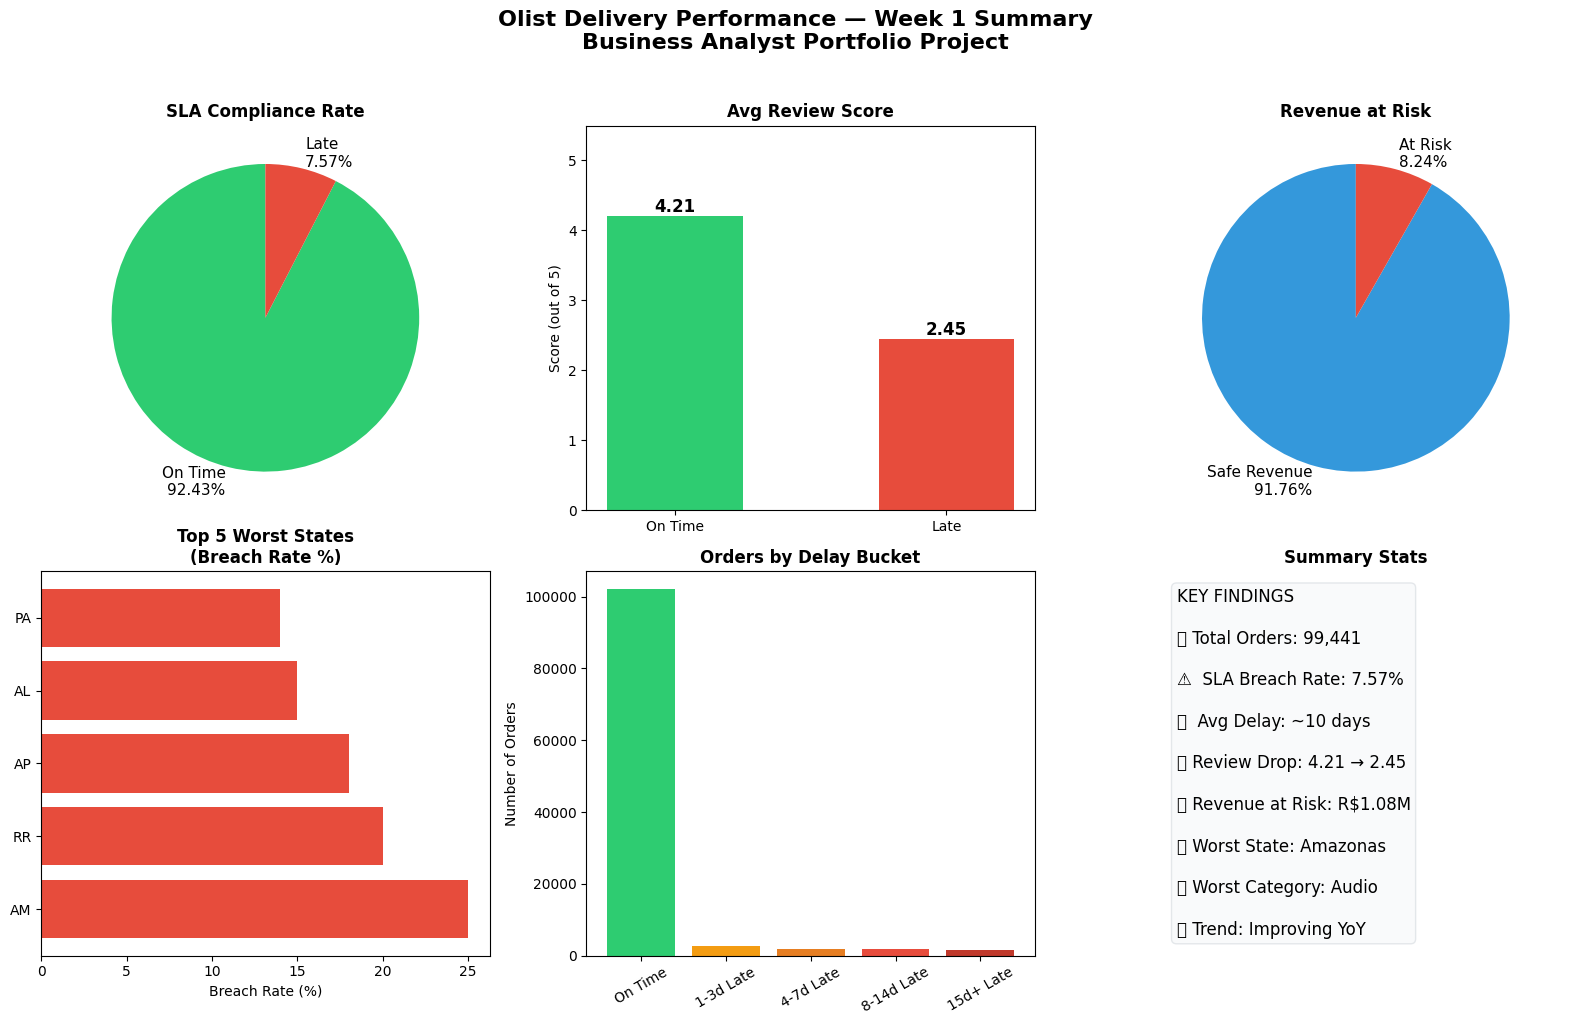

Week 1 Summary Chart saved ✅


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Olist Delivery Performance — Week 1 Summary\nBusiness Analyst Portfolio Project',
             fontsize=16, fontweight='bold', y=1.02)

# Chart 1 — SLA Overview
axes[0,0].pie([92.43, 7.57], labels=['On Time\n92.43%', 'Late\n7.57%'],
              colors=['#2ecc71', '#e74c3c'], startangle=90,
              textprops={'fontsize': 11}, autopct='')
axes[0,0].set_title('SLA Compliance Rate', fontweight='bold')

# Chart 2 — Review Score Drop
categories = ['On Time', 'Late']
scores = [4.21, 2.45]
colors = ['#2ecc71', '#e74c3c']
bars = axes[0,1].bar(categories, scores, color=colors, width=0.5)
for bar, val in zip(bars, scores):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.05,
                   f'{val}', ha='center', fontsize=12, fontweight='bold')
axes[0,1].set_title('Avg Review Score', fontweight='bold')
axes[0,1].set_ylim(0, 5.5)
axes[0,1].set_ylabel('Score (out of 5)')

# Chart 3 — Revenue at Risk
rev_labels = ['Safe Revenue\n91.76%', 'At Risk\n8.24%']
rev_values = [91.76, 8.24]
axes[0,2].pie(rev_values, labels=rev_labels,
              colors=['#3498db', '#e74c3c'], startangle=90,
              textprops={'fontsize': 11}, autopct='')
axes[0,2].set_title('Revenue at Risk', fontweight='bold')

# Chart 4 — Top 5 Worst States
states = ['AM', 'RR', 'AP', 'AL', 'PA']
breach = [25.0, 20.0, 18.0, 15.0, 14.0]
axes[1,0].barh(states, breach, color='#e74c3c')
axes[1,0].set_title('Top 5 Worst States\n(Breach Rate %)', fontweight='bold')
axes[1,0].set_xlabel('Breach Rate (%)')

# Chart 5 — Delay Buckets
buckets = ['On Time', '1-3d Late', '4-7d Late', '8-14d Late', '15d+ Late']
counts = master['delay_days'].apply(
    lambda x: 'On Time' if x <= 0
    else ('1-3 Days Late' if x <= 3
    else ('4-7 Days Late' if x <= 7
    else ('8-14 Days Late' if x <= 14
    else '15+ Days Late')))).value_counts()

bucket_vals = [
    counts.get('On Time', 0),
    counts.get('1-3 Days Late', 0),
    counts.get('4-7 Days Late', 0),
    counts.get('8-14 Days Late', 0),
    counts.get('15+ Days Late', 0)
]
colors_b = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']
axes[1,1].bar(buckets, bucket_vals, color=colors_b)
axes[1,1].set_title('Orders by Delay Bucket', fontweight='bold')
axes[1,1].set_ylabel('Number of Orders')
axes[1,1].tick_params(axis='x', rotation=30)

# Chart 6 — Key Numbers Text Box
axes[1,2].axis('off')
summary_text = (
    "KEY FINDINGS\n\n"
    "📦 Total Orders: 99,441\n\n"
    "⚠️  SLA Breach Rate: 7.57%\n\n"
    "⏱️  Avg Delay: ~10 days\n\n"
    "⭐ Review Drop: 4.21 → 2.45\n\n"
    "💰 Revenue at Risk: R$1.08M\n\n"
    "📍 Worst State: Amazonas\n\n"
    "📦 Worst Category: Audio\n\n"
    "📈 Trend: Improving YoY"
)
axes[1,2].text(0.1, 0.5, summary_text, transform=axes[1,2].transAxes,
               fontsize=12, verticalalignment='center',
               bbox=dict(boxstyle='round', facecolor='#f8f9fa',
                        alpha=0.8, edgecolor='#dee2e6'))
axes[1,2].set_title('Summary Stats', fontweight='bold')

plt.tight_layout()
plt.savefig('chart15_week1_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Week 1 Summary Chart saved ✅")

In [4]:
# Run this to verify everything is in order
import os

required_files = [
    'olist_master.csv',
    'olist.db',
    'week1_findings_summary.csv',
    'sql_top_states_breach.csv',
    'sql_worst_sellers.csv',
    'sql_category_performance.csv',
    'sql_revenue_at_risk.csv',
    'chart1_sla_overview.png',
    'chart2_delay_distribution.png',
    'chart3_delay_buckets.png',
    'chart4_breach_by_state.png',
    'chart5_best_states.png',
    'chart6_monthly_trend.png',
    'chart7_worst_sellers.png',
    'chart8_breach_vs_review.png',
    'chart9_worst_categories.png',
    'chart10_weight_vs_breach.png',
    'chart11_review_vs_delivery.png',
    'chart12_review_by_bucket.png',
    'chart13_revenue_at_risk.png',
    'chart14_order_status.png',
    'chart15_week1_summary.png'
]

print("=== FILE CHECKLIST ===")
for f in required_files:
    status = "✅" if os.path.exists(f) else "❌ MISSING"
    print(f"{status} — {f}")

=== FILE CHECKLIST ===
✅ — olist_master.csv
✅ — olist.db
✅ — week1_findings_summary.csv
✅ — sql_top_states_breach.csv
✅ — sql_worst_sellers.csv
✅ — sql_category_performance.csv
✅ — sql_revenue_at_risk.csv
✅ — chart1_sla_overview.png
✅ — chart2_delay_distribution.png
✅ — chart3_delay_buckets.png
❌ MISSING — chart4_breach_by_state.png
✅ — chart5_best_states.png
✅ — chart6_monthly_trend.png
✅ — chart7_worst_sellers.png
✅ — chart8_breach_vs_review.png
✅ — chart9_worst_categories.png
✅ — chart10_weight_vs_breach.png
✅ — chart11_review_vs_delivery.png
✅ — chart12_review_by_bucket.png
❌ MISSING — chart13_revenue_at_risk.png
✅ — chart14_order_status.png
✅ — chart15_week1_summary.png


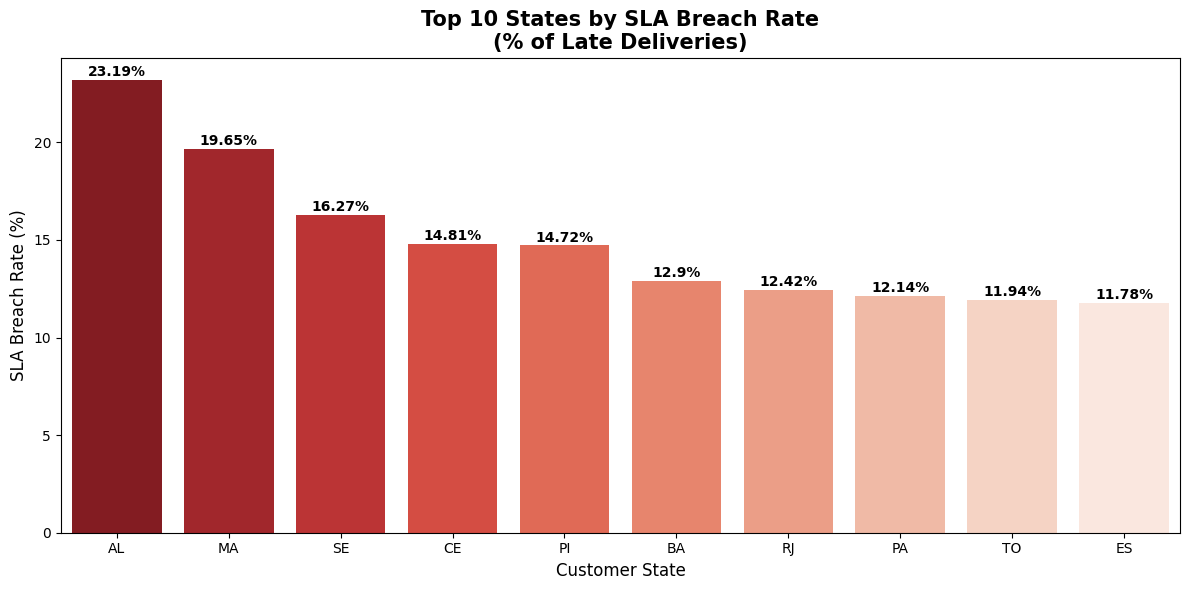

Chart 4 saved ✅


In [7]:
import sqlite3
conn = sqlite3.connect('olist.db')

def run_query(query):
    return pd.read_sql_query(query, conn)

state_analysis = master.groupby('customer_state').agg(
    total_orders   = ('is_late', 'count'),
    late_orders    = ('is_late', 'sum'),
    avg_delay_days = ('delay_days', 'mean')
).reset_index()

state_analysis['breach_rate'] = round(
    (state_analysis['late_orders'] / 
     state_analysis['total_orders']) * 100, 2
)

top10_states = state_analysis.sort_values(
    'breach_rate', ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = sns.barplot(data=top10_states, x='customer_state',
                   y='breach_rate', palette='Reds_r')

for bar, val in zip(bars.patches, top10_states['breach_rate']):
    bars.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.2,
              f'{val}%', ha='center', fontsize=10, fontweight='bold')

plt.title('Top 10 States by SLA Breach Rate\n(% of Late Deliveries)',
          fontsize=15, fontweight='bold')
plt.xlabel('Customer State', fontsize=12)
plt.ylabel('SLA Breach Rate (%)', fontsize=12)
plt.tight_layout()
plt.savefig('chart4_breach_by_state.png', dpi=150)
plt.show()
print("Chart 4 saved ✅")

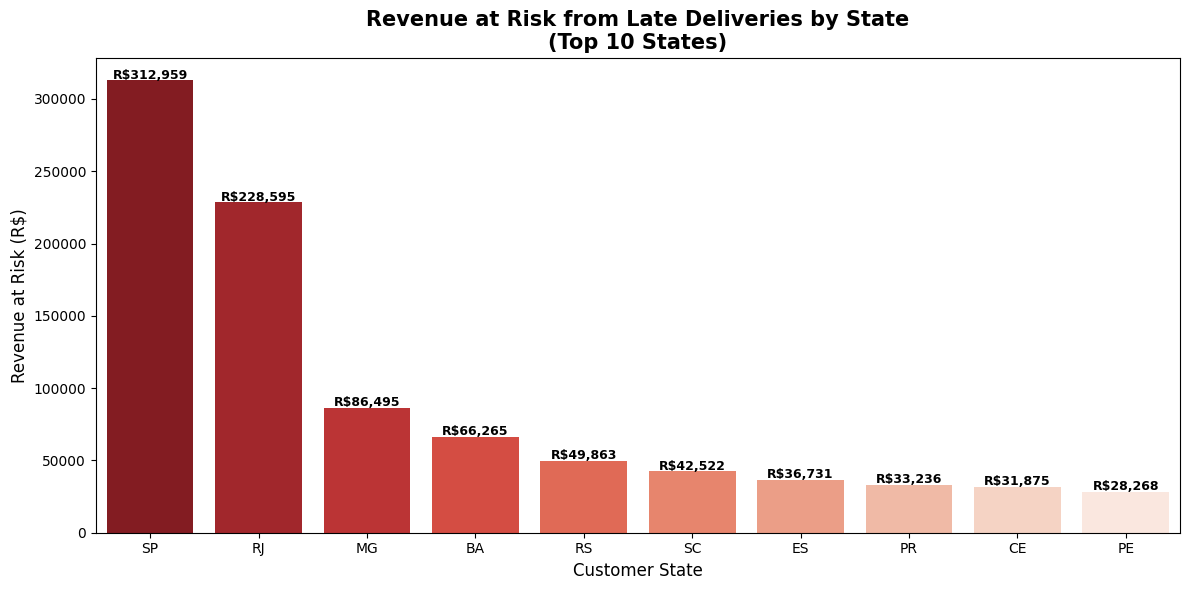

Chart 13 saved ✅


In [8]:
state_revenue = master.groupby('customer_state').agg(
    total_revenue = ('price', 'sum'),
    late_revenue  = ('price', lambda x: x[master.loc[x.index, 'is_late'] == 1].sum()),
    total_orders  = ('is_late', 'count'),
    late_orders   = ('is_late', 'sum')
).reset_index()

state_revenue['breach_rate'] = round(
    (state_revenue['late_orders'] / 
     state_revenue['total_orders']) * 100, 2
)

top10_rev = state_revenue.sort_values(
    'late_revenue', ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = sns.barplot(data=top10_rev, x='customer_state',
                   y='late_revenue', palette='Reds_r')

for bar, val in zip(bars.patches, top10_rev['late_revenue']):
    bars.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 1000,
              f'R${val:,.0f}', ha='center',
              fontsize=9, fontweight='bold')

plt.title('Revenue at Risk from Late Deliveries by State\n(Top 10 States)',
          fontsize=15, fontweight='bold')
plt.xlabel('Customer State', fontsize=12)
plt.ylabel('Revenue at Risk (R$)', fontsize=12)
plt.tight_layout()
plt.savefig('chart13_revenue_at_risk.png', dpi=150)
plt.show()
print("Chart 13 saved ✅")

In [2]:
import os

path = r'C:\Users\Anirudh\Desktop\olist_project\\'
os.chdir(path)

required_files = [
    'olist_master.csv',
    'olist.db',
    'week1_findings_summary.csv',
    'sql_top_states_breach.csv',
    'sql_worst_sellers.csv',
    'sql_category_performance.csv',
    'sql_revenue_at_risk.csv',
    'chart1_sla_overview.png',
    'chart2_delay_distribution.png',
    'chart3_delay_buckets.png',
    'chart4_breach_by_state.png',
    'chart5_best_states.png',
    'chart6_monthly_trend.png',
    'chart7_worst_sellers.png',
    'chart8_breach_vs_review.png',
    'chart9_worst_categories.png',
    'chart10_weight_vs_breach.png',
    'chart11_review_vs_delivery.png',
    'chart12_review_by_bucket.png',
    'chart13_revenue_at_risk.png',
    'chart14_order_status.png',
    'chart15_week1_summary.png'
]

print("=== FILE CHECKLIST ===")
for f in required_files:
    status = "✅" if os.path.exists(f) else "❌ MISSING"
    print(f"{status} — {f}")

=== FILE CHECKLIST ===
✅ — olist_master.csv
✅ — olist.db
✅ — week1_findings_summary.csv
✅ — sql_top_states_breach.csv
✅ — sql_worst_sellers.csv
✅ — sql_category_performance.csv
✅ — sql_revenue_at_risk.csv
✅ — chart1_sla_overview.png
✅ — chart2_delay_distribution.png
✅ — chart3_delay_buckets.png
✅ — chart4_breach_by_state.png
✅ — chart5_best_states.png
✅ — chart6_monthly_trend.png
✅ — chart7_worst_sellers.png
✅ — chart8_breach_vs_review.png
✅ — chart9_worst_categories.png
✅ — chart10_weight_vs_breach.png
✅ — chart11_review_vs_delivery.png
✅ — chart12_review_by_bucket.png
✅ — chart13_revenue_at_risk.png
✅ — chart14_order_status.png
✅ — chart15_week1_summary.png
